# 02 — Exploration des données formattées (Yahoo Finance)

Lecture du fichier `formatted/yahoofinance/wti.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_yfinance.py`.

In [38]:
import io
import os
import boto3
import pandas as pd

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du parquet formatté (dossier Spark) ──
# Spark écrit un dossier wti.parquet/ contenant _SUCCESS + part-*.parquet
prefix = "formatted/yahoofinance/wti.parquet/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_key = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")][0]

response = s3.get_object(Bucket="datalake", Key=parquet_key)
df = pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow")

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nPlage : {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Shape : 848 lignes × 8 colonnes

Types :
Datetime            datetime64[ns]
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
Volatility_Range           float64
Variation_Pct              float64
dtype: object

Plage : 2026-02-16 00:00:00 → 2026-03-02 04:45:00


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
0,2026-02-16 00:00:00,62.930000,62.939999,62.869999,62.900002,126,0.07,NaN
1,2026-02-16 00:15:00,62.880001,62.930000,62.869999,62.930000,90,0.06,-0.0795
2,2026-02-16 00:30:00,62.880001,62.900002,62.869999,62.880001,38,0.03,0.0000
3,2026-02-16 00:45:00,62.860001,62.900002,62.830002,62.880001,144,0.07,-0.0318
4,2026-02-16 01:00:00,62.880001,62.930000,62.840000,62.860001,136,0.09,0.0318


In [39]:
# ── Vérification qualité ──
print("Valeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons sur Datetime : {df.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques :")
df.describe().round(2)

Valeurs manquantes :
Datetime            0
Close               0
High                0
Low                 0
Open                0
Volume              0
Volatility_Range    0
Variation_Pct       1
dtype: int64

Doublons sur Datetime : 0

Statistiques :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
count,848,848.00,848.00,848.00,848.00,848.00,848.00,847.00
mean,2026-02-22 18:13:26.603773440,65.55,65.65,65.44,65.55,3853.68,0.21,0.02
min,2026-02-16 00:00:00,61.86,61.99,61.76,61.86,38.00,0.03,-2.00
25%,2026-02-19 06:56:15,65.08,65.17,64.99,65.07,676.75,0.11,-0.09
50%,2026-02-23 13:52:30,65.90,65.98,65.79,65.89,1932.50,0.16,0.02
75%,2026-02-25 20:48:45,66.41,66.51,66.29,66.40,5351.25,0.25,0.11
max,2026-03-02 04:45:00,72.53,73.00,72.27,72.54,46560.00,1.76,7.79
std,NaN,1.67,1.69,1.64,1.67,4893.06,0.17,0.35


In [40]:
# ── Aperçu dernières lignes ──
print("Dernières lignes :")
df.tail(50)

Dernières lignes :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
798,2026-02-27 15:30:00,66.959999,66.980003,66.489998,66.930000,16115,0.49,0.0598
799,2026-02-27 15:45:00,66.910004,67.029999,66.809998,66.959999,7342,0.22,-0.0747
800,2026-02-27 16:00:00,66.809998,66.919998,66.699997,66.900002,9738,0.22,-0.1495
801,2026-02-27 16:15:00,66.510002,66.820000,66.510002,66.809998,12397,0.31,-0.4490
802,2026-02-27 16:30:00,66.550003,66.669998,66.449997,66.510002,6337,0.22,0.0601
803,2026-02-27 16:45:00,66.540001,66.570000,66.419998,66.529999,7116,0.15,-0.0150
804,2026-02-27 17:00:00,66.739998,66.800003,66.480003,66.540001,6047,0.32,0.3006
805,2026-02-27 17:15:00,66.650002,66.779999,66.570000,66.750000,4273,0.21,-0.1348
806,2026-02-27 17:30:00,66.550003,66.800003,66.129997,66.660004,26871,0.67,-0.1500
807,2026-02-27 17:45:00,66.760002,66.779999,66.510002,66.559998,6479,0.27,0.3156


---
# Exploration des données formattées (GDELT)

Lecture du fichier `formatted/gdelt/events.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_gdelt.py`.

In [41]:
# ═══════════════════════════════════════════════
# Chargement du Parquet formatté GDELT depuis S3
# ═══════════════════════════════════════════════
prefix_gdelt = "formatted/gdelt/events.parquet/"
objs_gdelt = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gdelt)
parquet_keys_gdelt = [o["Key"] for o in objs_gdelt.get("Contents", []) if o["Key"].endswith(".parquet")]

# Spark peut écrire plusieurs partitions → on les concat
dfs = []
for key in parquet_keys_gdelt:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gdelt = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Shape : {df_gdelt.shape[0]} lignes × {df_gdelt.shape[1]} colonnes")
print(f"\nTypes :\n{df_gdelt.dtypes}")
print(f"\nColonnes : {list(df_gdelt.columns)}")
df_gdelt.head()

Shape : 191662 lignes × 28 colonnes

Types :
GlobalEventID                     int64
Day                              object
DATEADDED                datetime64[ns]
Actor1Code                       object
Actor1Name                       object
Actor1CountryCode                object
Actor1Type1Code                  object
Actor2Code                       object
Actor2Name                       object
Actor2CountryCode                object
Actor2Type1Code                  object
EventCode                         int32
EventRootCode                     int32
QuadClass                         int32
GoldsteinScale                  float64
IsRootEvent                       int32
ActionGeo_CountryCode            object
ActionGeo_Lat                   float64
ActionGeo_Long                  float64
NumMentions                       int32
NumSources                        int32
NumArticles                       int32
AvgTone                         float64
geo_I                           flo

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country
0,1289336305,2026-02-16,2026-02-15 23:00:00,None,None,None,None,COP,POLICE,None,...,-75.700,10,1,10,-3.214286,1.0,2.397895,1.782143,4.273392,None
1,1289336414,2026-02-16,2026-02-15 23:00:00,AUS,AUSTRALIA,AUS,None,None,None,None,...,151.000,6,1,6,-6.926407,1.0,1.945910,1.819264,3.540124,AUS
2,1289336418,2026-02-16,2026-02-15 23:00:00,AUSCOP,SYDNEY,AUS,COP,POL,POLE,POL,...,151.217,6,1,6,-8.000000,1.0,1.945910,2.505000,4.874505,AUS
3,1289336526,2026-02-16,2026-02-15 23:00:00,COP,POLICE OFFICER,None,COP,CAN,CANADA,CAN,...,-75.700,4,1,4,-3.214286,3.0,1.609438,1.032143,14.950529,CAN
4,1289336670,2026-02-16,2026-02-15 23:00:00,GOV,GOVERNMENT,None,GOV,None,None,None,...,135.000,10,1,10,-0.958904,1.0,2.397895,1.009589,2.420889,None


In [42]:
print(df_gdelt.columns)

Index(['GlobalEventID', 'Day', 'DATEADDED', 'Actor1Code', 'Actor1Name',
       'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2Type1Code', 'EventCode', 'EventRootCode',
       'QuadClass', 'GoldsteinScale', 'IsRootEvent', 'ActionGeo_CountryCode',
       'ActionGeo_Lat', 'ActionGeo_Long', 'NumMentions', 'NumSources',
       'NumArticles', 'AvgTone', 'geo_I', 'geo_B', 'geo_S', 'geo_score_raw',
       'dominant_country'],
      dtype='object')


In [43]:
# ═══════════════════════════════════════════════
# Statistiques descriptives GDELT
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gdelt.isnull().sum())
print(f"\nDoublons sur GlobalEventID : {df_gdelt.duplicated(subset=['GlobalEventID']).sum()}")
print(f"\nPlage temporelle : {df_gdelt['DATEADDED'].min()} → {df_gdelt['DATEADDED'].max()}")
print(f"\nStatistiques numériques :")
df_gdelt.describe().round(2)

Valeurs manquantes :
GlobalEventID                 0
Day                           0
DATEADDED                     0
Actor1Code                19859
Actor1Name                19859
Actor1CountryCode         96709
Actor1Type1Code          100158
Actor2Code                63170
Actor2Name                63170
Actor2CountryCode        120823
Actor2Type1Code          124230
EventCode                     0
EventRootCode                 0
QuadClass                     0
GoldsteinScale                0
IsRootEvent                   0
ActionGeo_CountryCode     12119
ActionGeo_Lat             12198
ActionGeo_Long            12160
NumMentions                   0
NumSources                    0
NumArticles                   0
AvgTone                       0
geo_I                         0
geo_B                         0
geo_S                         0
geo_score_raw                 0
dominant_country          71354
dtype: int64

Doublons sur GlobalEventID : 0

Plage temporelle : 2026-02-15 23:00:0

,GlobalEventID,DATEADDED,EventCode,EventRootCode,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw
count,1.916620e+05,191662,191662.00,191662.00,191662.00,191662.00,191662.00,179464.00,179502.00,191662.00,191662.00,191662.00,191662.00,191662.00,191662.00,191662.00,191662.00
mean,1.290640e+09,2026-02-23 10:43:48.389561088,237.66,14.32,3.34,-4.00,0.61,31.04,-5.34,7.32,1.09,7.11,-3.99,2.25,2.02,1.89,26.63
min,1.289336e+09,2026-02-15 23:00:00,60.00,6.00,2.00,-10.00,0.00,-85.62,-179.77,4.00,1.00,4.00,-31.25,1.00,1.61,1.00,1.61
25%,1.290007e+09,2026-02-19 14:45:00,100.00,8.00,2.00,-10.00,0.00,25.67,-81.72,5.00,1.00,4.00,-6.67,1.00,1.61,1.10,4.03
50%,1.290648e+09,2026-02-23 20:45:00,173.00,17.00,4.00,-5.00,1.00,35.00,4.33,6.00,1.00,6.00,-3.98,2.00,1.95,1.85,7.09
75%,1.291279e+09,2026-02-27 00:30:00,190.00,19.00,4.00,5.00,1.00,42.15,51.51,10.00,1.00,10.00,-1.30,4.00,2.40,2.50,45.56
max,1.291910e+09,2026-03-02 14:00:00,1832.00,20.00,4.00,10.00,1.00,81.50,179.48,940.00,20.00,310.00,17.65,5.50,5.74,2.79,340.57
std,7.397340e+05,NaN,314.71,4.82,0.86,6.44,0.49,19.62,77.59,5.16,0.59,4.27,4.17,1.42,0.35,0.59,31.76


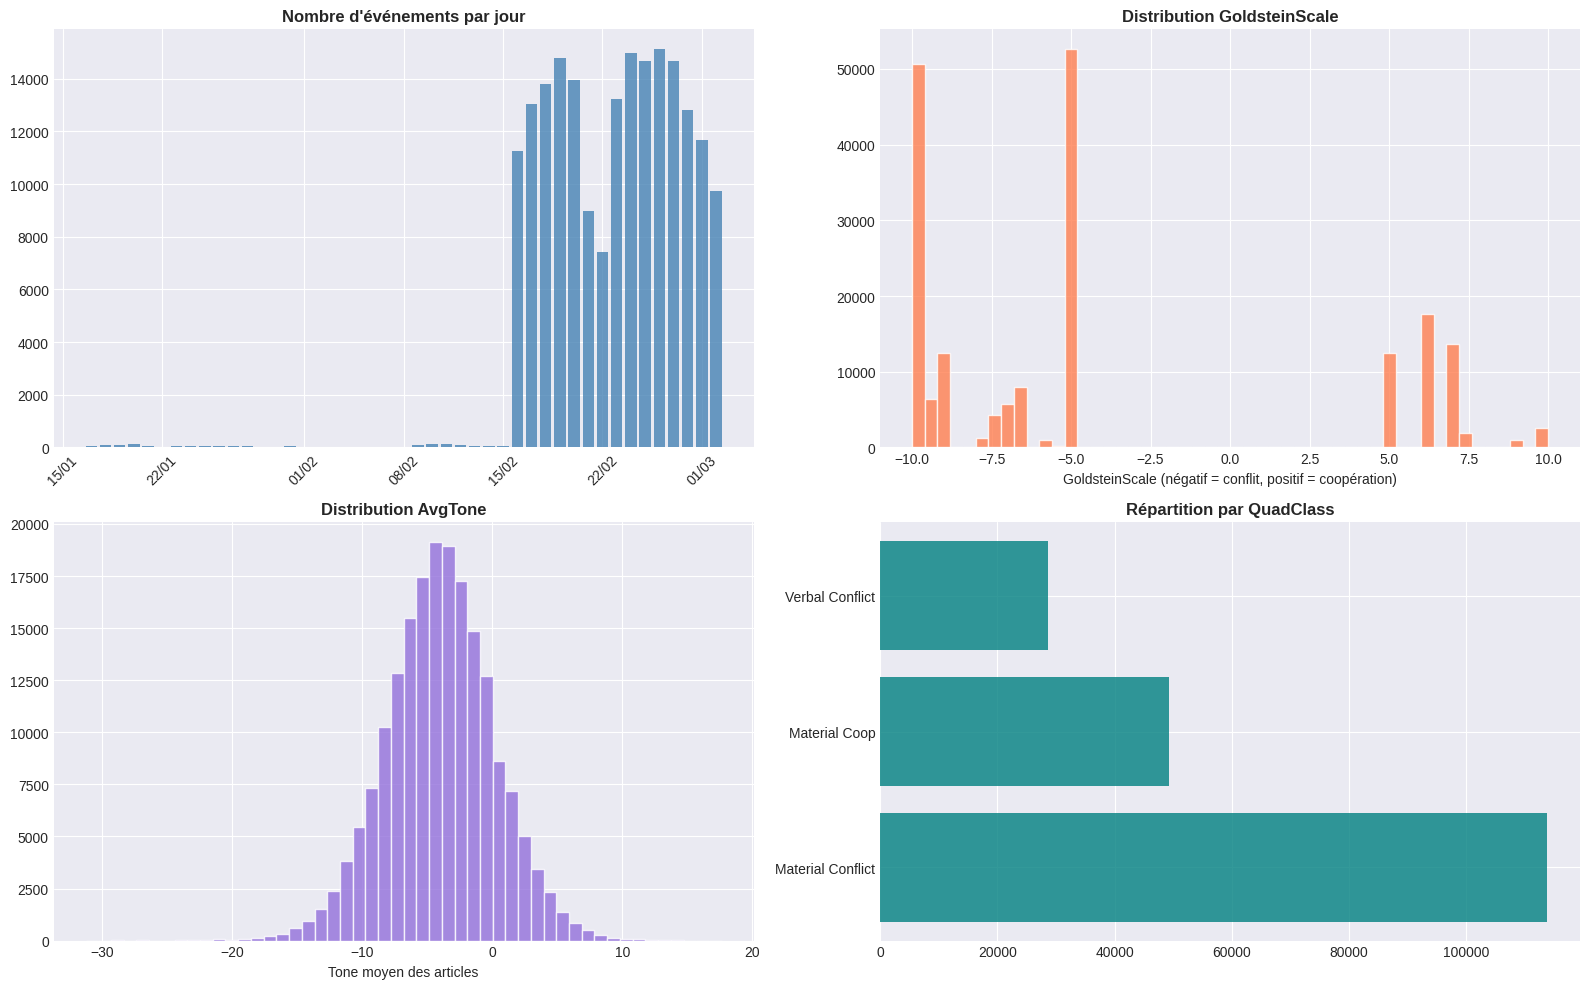

In [44]:
# ═══════════════════════════════════════════════
# Distribution des événements GDELT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Nombre d'événements par jour
if "Day" in df_gdelt.columns:
    df_gdelt["Day_dt"] = pd.to_datetime(df_gdelt["Day"], format="%Y%m%d", errors="coerce")
    daily = df_gdelt.groupby("Day_dt").size()
    axes[0, 0].bar(daily.index, daily.values, color="steelblue", alpha=0.8)
    axes[0, 0].set_title("Nombre d'événements par jour", fontweight="bold")
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution GoldsteinScale
if "GoldsteinScale" in df_gdelt.columns:
    axes[0, 1].hist(df_gdelt["GoldsteinScale"].dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white")
    axes[0, 1].set_title("Distribution GoldsteinScale", fontweight="bold")
    axes[0, 1].set_xlabel("GoldsteinScale (négatif = conflit, positif = coopération)")

# 3. Distribution AvgTone
if "AvgTone" in df_gdelt.columns:
    axes[1, 0].hist(df_gdelt["AvgTone"].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[1, 0].set_title("Distribution AvgTone", fontweight="bold")
    axes[1, 0].set_xlabel("Tone moyen des articles")

# 4. Top 10 QuadClass
if "QuadClass" in df_gdelt.columns:
    top_quad = df_gdelt["QuadClass"].value_counts().head(10)
    quad_labels = {1: "Verbal Coop", 2: "Material Coop", 3: "Verbal Conflict", 4: "Material Conflict"}
    top_quad.index = [quad_labels.get(int(x), str(x)) for x in top_quad.index]
    axes[1, 1].barh(top_quad.index, top_quad.values, color="teal", alpha=0.8)
    axes[1, 1].set_title("Répartition par QuadClass", fontweight="bold")

plt.tight_layout()
plt.show()

In [45]:
# ═══════════════════════════════════════════════
# Aperçu dernières lignes GDELT
# ═══════════════════════════════════════════════
print(f"Dernières lignes :")
df_gdelt.tail(200)

Dernières lignes :


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt
191462,1291905168,2026-03-02,2026-03-02 13:45:00,None,None,None,None,MIL,MILITARY PERSONNEL,None,...,8,1,8,-3.111111,1.0,2.197225,2.531111,5.561420,None,2026-03-02
191463,1291905222,2026-03-02,2026-03-02 13:45:00,ARE,DUBAI,ARE,None,None,None,None,...,10,1,10,-4.624277,3.0,2.397895,1.046243,22.579025,ARE,2026-03-02
191464,1291905228,2026-03-02,2026-03-02 13:45:00,ARE,UNITED ARAB EMIRATES,ARE,None,IRN,IRAN,IRN,...,10,1,10,-3.577236,4.0,2.397895,1.035772,39.738778,ARE,2026-03-02
191465,1291905379,2026-03-02,2026-03-02 13:45:00,COP,POLICE,None,COP,None,None,None,...,10,1,10,-8.666667,1.0,2.397895,1.086667,2.605713,None,2026-03-02
191466,1291905394,2026-03-02,2026-03-02 13:45:00,COP,POLICE,None,COP,GOV,GOVERNMENT,None,...,8,1,8,-9.565217,1.0,2.197225,2.175652,4.780396,None,2026-03-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191657,1291910288,2026-03-02,2026-03-02 14:00:00,USA,UNITED STATES,USA,None,ISR,ISRAEL,ISR,...,4,1,4,0.649351,4.5,1.609438,1.750000,57.034456,USA,2026-03-02
191658,1291910311,2026-03-02,2026-03-02 14:00:00,USA,UNITED STATES,USA,None,MIL,MILITARY,None,...,4,1,4,-4.719764,4.0,1.609438,1.797198,46.279648,USA,2026-03-02
191659,1291909168,2026-03-02,2026-03-02 14:00:00,CAN,CANADA,CAN,None,USA,AMERICAN,USA,...,5,1,5,2.109705,5.0,1.791759,1.750000,78.389477,USA,2026-03-02
191660,1291909819,2026-03-02,2026-03-02 14:00:00,LBNGOVHLH,LEBANON,LBN,GOV,ISR,ISRAELI,ISR,...,10,1,10,-6.813187,2.0,2.397895,2.568132,24.632445,ISR,2026-03-02


In [46]:
# ═══════════════════════════════════════════════
# Affichage des 20 premières lignes GDELT
# ═══════════════════════════════════════════════
df_gdelt.head(100)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt
0,1289336305,2026-02-16,2026-02-15 23:00:00,None,None,None,None,COP,POLICE,None,...,10,1,10,-3.214286,1.0,2.397895,1.782143,4.273392,None,2026-02-16
1,1289336414,2026-02-16,2026-02-15 23:00:00,AUS,AUSTRALIA,AUS,None,None,None,None,...,6,1,6,-6.926407,1.0,1.945910,1.819264,3.540124,AUS,2026-02-16
2,1289336418,2026-02-16,2026-02-15 23:00:00,AUSCOP,SYDNEY,AUS,COP,POL,POLE,POL,...,6,1,6,-8.000000,1.0,1.945910,2.505000,4.874505,AUS,2026-02-16
3,1289336526,2026-02-16,2026-02-15 23:00:00,COP,POLICE OFFICER,None,COP,CAN,CANADA,CAN,...,4,1,4,-3.214286,3.0,1.609438,1.032143,14.950529,CAN,2026-02-16
4,1289336670,2026-02-16,2026-02-15 23:00:00,GOV,GOVERNMENT,None,GOV,None,None,None,...,10,1,10,-0.958904,1.0,2.397895,1.009589,2.420889,None,2026-02-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1289336677,2026-02-16,2026-02-15 23:00:00,GOV,REGIME,None,GOV,None,None,None,...,6,2,6,-1.399581,1.0,1.945910,1.763996,3.432577,None,2026-02-16
96,1289336733,2026-02-16,2026-02-15 23:00:00,GOV,ADMINISTRATION,None,GOV,VEN,VENEZUELA,VEN,...,9,2,9,-4.251743,2.0,2.302585,2.467517,22.726675,VEN,2026-02-16
97,1289336856,2026-02-16,2026-02-15 23:00:00,LEG,CONGRESS,None,LEG,None,None,None,...,10,1,10,-0.468384,1.0,2.397895,1.004684,2.409127,None,2026-02-16
98,1289336869,2026-02-16,2026-02-15 23:00:00,LEG,SENATOR,None,LEG,REF,DISPLACED PERSON,None,...,5,1,5,4.270463,1.0,1.791759,1.975000,3.538725,None,2026-02-16


In [47]:
print(df_gdelt.iloc[110])

GlobalEventID                     1289336880
Day                               2026-02-16
DATEADDED                2026-02-15 23:00:00
Actor1Code                               LKA
Actor1Name                         SRI LANKA
Actor1CountryCode                        LKA
Actor1Type1Code                         None
Actor2Code                               JUD
Actor2Name                            LAWYER
Actor2CountryCode                       None
Actor2Type1Code                          JUD
EventCode                                874
EventRootCode                              8
QuadClass                                  2
GoldsteinScale                          10.0
IsRootEvent                                1
ActionGeo_CountryCode                     CE
ActionGeo_Lat                        6.93194
ActionGeo_Long                       79.8478
NumMentions                               10
NumSources                                 1
NumArticles                               10
AvgTone   

In [48]:
# Filtrer les lignes avec OPC en Actor1Code ou Actor2Code
df_opc = df_gdelt[(df_gdelt['Actor1Code'] == 'GOVOPC') | (df_gdelt['Actor2Code'] == 'GOVOPC')]

print(f"Nombre de lignes avec OPC : {len(df_opc)}")
df_opc.head(50)

Nombre de lignes avec OPC : 0


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,NumMentions,NumSources,NumArticles,AvgTone,geo_I,geo_B,geo_S,geo_score_raw,dominant_country,Day_dt


In [49]:
import numpy as np

# ═══════════════════════════════════════════════
# Ajout des colonnes "buzz" et "gravité pondérée"
# ═══════════════════════════════════════════════


# Création d'une copie du dataset filtré pour ajouter les nouvelles colonnes
df_gdelt_enriched = filter_all.copy()

# Calcul de "Le buzz" : log(1 + NumArticles)
df_gdelt_enriched['buzz'] = np.log(1 + df_gdelt_enriched['NumArticles'])

# Calcul de "La Gravité pondérée" : (10 - Goldstein) × (1 + (100 - AvgTone) / 50)
df_gdelt_enriched['gravite_ponderee'] = (
    (10 - df_gdelt_enriched['GoldsteinScale']) * 
    (1 + (100 - df_gdelt_enriched['AvgTone']) / 50)
)

print(f"✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'")
print(f"📊 Shape du dataset enrichi : {df_gdelt_enriched.shape[0]} lignes × {df_gdelt_enriched.shape[1]} colonnes\n")
print("=" * 150)
print("Aperçu des 100 premières lignes :\n")
df_gdelt_enriched.head(100)
df_gdelt_enriched.describe()


NameError: name 'filter_all' is not defined

In [ ]:
# ═══════════════════════════════════════════════
# Analyse de l'impact des filtres avec EventRootCode
# ═══════════════════════════════════════════════

relevant_event_codes = [6, 8,10,11,12, 13, 14, 15, 16, 17, 18, 19, 20]

df_base = df_gdelt.copy()
total = len(df_base)

# Calcul de chaque filtre individuellement
f_eventroot = df_base['EventRootCode'].isin(relevant_event_codes)
f_numart    = df_base['NumArticles'] >= 4
f_goldstein = df_base['GoldsteinScale'].abs() >= 5
f_quadclass = df_base['QuadClass'] >= 2

# Construction du tableau d'impact
filters_summary = [
    ("Aucun filtre (données initiales)",                       total),
    ("EventRootCode ∈ liste",                                  f_eventroot.sum()),
    ("NumArticles >= 4",                                       f_numart.sum()),
    ("|GoldsteinScale| >= 5",                                  f_goldstein.sum()),
    ("QuadClass >= 2",                                         f_quadclass.sum()),
    ("EventRootCode ∈ liste ET NumArticles >= 4",              (f_eventroot & f_numart).sum()),
    ("EventRootCode ∈ liste ET |GoldsteinScale| >= 5",         (f_eventroot & f_goldstein).sum()),
    ("EventRootCode ∈ liste ET QuadClass >= 2",                (f_eventroot & f_quadclass).sum()),
    ("NumArticles >= 4 ET |GoldsteinScale| >= 5",              (f_numart & f_goldstein).sum()),
    ("NumArticles >= 4 ET QuadClass >= 2",                     (f_numart & f_quadclass).sum()),
    ("|GoldsteinScale| >= 5 ET QuadClass >= 2",                (f_goldstein & f_quadclass).sum()),
    ("TOUS LES FILTRES COMBINÉS",                              (f_numart & f_goldstein & f_quadclass).sum()),
]

results_extended = pd.DataFrame(filters_summary, columns=["Filtre(s) appliqué(s)", "Nombre de lignes"])
results_extended["% restant"]  = (results_extended["Nombre de lignes"] / total * 100).round(2)
results_extended["Lignes retirées"] = total - results_extended["Nombre de lignes"]
results_extended["% retiré"]   = (results_extended["Lignes retirées"] / total * 100).round(2)

print(f"Total initial : {total:,} lignes\n")
print(f"Codes EventRootCode conservés : {relevant_event_codes}\n")
display(results_extended)

# Aperçu du dataset final avec tous les filtres combinés
df_final = df_base[f_numart & f_goldstein & f_quadclass].copy()
print(f"\n✅ Dataset final (tous filtres) : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")
df_final.head(20)

In [ ]:
# Affichage des 20 premières lignes du GDELT
df_gdelt.head(20)